<a href="https://colab.research.google.com/github/Sparten-Ashvinee/IISc-LLM/blob/main/Assignments/Inference_profiling_and_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yaml
import torch
import matplotlib.pyplot as plt
from transformers import GPT2Config, GPT2LMHeadModel, GPT2Tokenizer

In [2]:
class GPT2_Model:
    def __init__(self, config):
        self.config = config

    def model(self):
        self.configuration = GPT2Config(**self.config)
        self.configuration._attn_implementation = "eager"
        self.model_ = GPT2LMHeadModel(self.configuration)

        return self.model_

    def print_param(self, model):

        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")

        fp32_bytes = total_params * 4
        fp16_bytes = total_params * 2

        print(f"FP32 memory: {fp32_bytes / 1024**2:.2f} MB")
        print(f"FP16 memory: {fp16_bytes / 1024**2:.2f} MB")

        param_memory = fp32_bytes/1024**2
        return param_memory

In [3]:
def get_register_hook(module):
    def get_forward_hook(name):
        def forward_hook_fun(module, inp, out):
            if isinstance(module, torch.nn.Embedding):
                x = inp[0]
                print('Embedding: ',name,'has shape: ',out.shape)
            if 'c_attn' in name:
                print('Attention: ',name,'has shape: ',out.reshape((out.shape[0],3,out.shape[1],out.shape[2]//3)).shape)
            if 'act' in name:
                print("Activation dim:", out.shape)
            if 'ln_f' in name:
                print("LayerNorm dim:", out.shape)
        return forward_hook_fun

    for name, layer in module.named_modules():
        layer.register_forward_hook(get_forward_hook(name))

In [5]:
data_path = '/content/data.txt'
with open(data_path, 'r', encoding='utf-8') as f:
    raw_text = f.read()

tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2")

# Use GPU if available, else fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
device

device(type='cpu')

In [7]:
#GPT2 Small Model
print("\nGPT2 Small:")
with open("/content/gpt2_large.yaml", "r") as f:
    config_small = yaml.safe_load(f)

#print(config_small)
gpt2_small = GPT2_Model(config_small)
gpt2_small_model = gpt2_small.model()
gpt2_small_model = gpt2_small_model.to(device)

inputs = tokenizer(raw_text, return_tensors="pt").to(device)

get_register_hook(gpt2_small_model)

input_test = inputs.input_ids[0][:1024]
#print(input_test)
with torch.no_grad():
    outputs = gpt2_small_model(input_test.unsqueeze(0), labels=input_test.unsqueeze(0), output_attentions=True)

print("Attention scores dim:", outputs.attentions[0].shape)

small_act_memory=outputs.attentions[0].shape[0] * outputs.attentions[0].shape[1] * outputs.attentions[0].shape[2] * outputs.attentions[0].shape[3] * 4/1024**2

#small_act_memory=max(act_memory)
print("Peak activation memory:",small_act_memory, "MB")

small_param_memory = gpt2_small.print_param(gpt2_small_model)

# Free Small model before loading Medium
del gpt2_small_model, gpt2_small, outputs, inputs
torch.cuda.empty_cache()


GPT2 Small:


Token indices sequence length is longer than the specified maximum sequence length for this model (5145 > 1024). Running this sequence through the model will result in indexing errors


Embedding:  transformer.wte has shape:  torch.Size([1, 1024, 1280])
Embedding:  transformer.wpe has shape:  torch.Size([1, 1024, 1280])
Attention:  transformer.h.0.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.1.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.2.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.3.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.4.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.5.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.6.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: tor

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Attention scores dim: torch.Size([1, 20, 1024, 1024])
Peak activation memory: 80.0 MB
Total parameters: 774,357,760
FP32 memory: 2953.94 MB
FP16 memory: 1476.97 MB


In [7]:

#GPT2 Medium Model
print("\nGPT2 Medium:")
with open("gpt2_medium.yaml", "r") as f:
    config_medium = yaml.safe_load(f)

gpt2_medium = GPT2_Model(config_medium)
gpt2_medium_model = gpt2_medium.model().to(device)

inputs = tokenizer(raw_text, return_tensors="pt").to(device)

get_register_hook(gpt2_medium_model)

input_test = inputs.input_ids[0][:1024]
with torch.no_grad():
    outputs = gpt2_medium_model(input_test.unsqueeze(0), labels=input_test.unsqueeze(0), output_attentions=True)

print("Attention scores dim:", outputs.attentions[0].shape)

# act_memory=[]
# for idx in range(len(outputs.attentions)):
#     mem = outputs.attentions[idx].shape[0] * outputs.attentions[idx].shape[1] * outputs.attentions[idx].shape[2] * outputs.attentions[idx].shape[3] * 4/1024**2
#     print("Memory Bottleneck", mem, "MB")
#     act_memory.append(mem)

#medium_act_memory=max(act_memory)

medium_act_memory=outputs.attentions[0].shape[0] * outputs.attentions[0].shape[1] * outputs.attentions[0].shape[2] * outputs.attentions[0].shape[3] * 4/1024**2
print("Peak activation memory:",medium_act_memory, "MB")

medium_param_memory = gpt2_medium.print_param(gpt2_medium_model)

# Free Medium model before loading Large
del gpt2_medium_model, gpt2_medium, outputs, inputs
torch.cuda.empty_cache()


GPT2 Medium:
Embedding:  transformer.wte has shape:  torch.Size([1, 1024, 1024])
Embedding:  transformer.wpe has shape:  torch.Size([1, 1024, 1024])
Attention:  transformer.h.0.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activation dim: torch.Size([1, 1024, 4096])
Attention:  transformer.h.1.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activation dim: torch.Size([1, 1024, 4096])
Attention:  transformer.h.2.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activation dim: torch.Size([1, 1024, 4096])
Attention:  transformer.h.3.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activation dim: torch.Size([1, 1024, 4096])
Attention:  transformer.h.4.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activation dim: torch.Size([1, 1024, 4096])
Attention:  transformer.h.5.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activation dim: torch.Size([1, 1024, 4096])
Attention:  transformer.h.6.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1024])
Activ

In [9]:
#GPT2 Large Model
print("\nGPT2 Large:")
with open("gpt2_large.yaml", "r") as f:
    config_large = yaml.safe_load(f)

gpt2_large = GPT2_Model(config_large)
gpt2_large_model = gpt2_large.model().to(device)

inputs = tokenizer(raw_text, return_tensors="pt").to(device)

get_register_hook(gpt2_large_model)

input_test = inputs.input_ids[0][:1024]
with torch.no_grad():
    outputs = gpt2_large_model(input_test.unsqueeze(0), labels=input_test.unsqueeze(0), output_attentions=True)

print("Attention scores dim:", outputs.attentions[0].shape)

# act_memory=[]
# for idx in range(len(outputs.attentions)):
#     mem = outputs.attentions[idx].shape[0] * outputs.attentions[idx].shape[1] * outputs.attentions[idx].shape[2] * outputs.attentions[idx].shape[3] * 4/1024**2
#     print("Memory Bottleneck", mem, "MB")
#     act_memory.append(mem)

#large_act_memory=max(act_memory)
large_act_memory=outputs.attentions[0].shape[0] * outputs.attentions[0].shape[1] * outputs.attentions[0].shape[2] * outputs.attentions[0].shape[3] * 4/1024**2
print("Peak activation memory:",large_act_memory, "MB")

large_param_memory = gpt2_large.print_param(gpt2_large_model)


GPT2 Large:
Embedding:  transformer.wte has shape:  torch.Size([1, 1024, 1280])
Embedding:  transformer.wpe has shape:  torch.Size([1, 1024, 1280])
Attention:  transformer.h.0.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.1.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.2.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.3.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.4.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.5.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activation dim: torch.Size([1, 1024, 5120])
Attention:  transformer.h.6.attn.c_attn has shape:  torch.Size([1, 3, 1024, 1280])
Activa

In [10]:
print("Ratio act/param memory for GPT2 Small:", small_act_memory/small_param_memory)
print("Ratio act/param memory for GPT2 Medium:", medium_act_memory/medium_param_memory)
print("Ratio act/param memory for GPT2 Large:", large_act_memory/large_param_memory)

Ratio act/param memory for GPT2 Small: 0.027082468961116886
Ratio act/param memory for GPT2 Medium: 0.047283316065764906
Ratio act/param memory for GPT2 Large: 0.027082468961116886


In [11]:
if small_act_memory/small_param_memory > medium_act_memory/medium_param_memory and small_act_memory/small_param_memory > large_act_memory/large_param_memory:
    print("GPT2 Small has negligible activation")
elif medium_act_memory/medium_param_memory > small_act_memory/small_param_memory and medium_act_memory/medium_param_memory > large_act_memory/large_param_memory:
    print("GPT2 Medium has negligible activation")
else:
    print("GPT2 Large has negligible activation")

GPT2 Medium has negligible activation


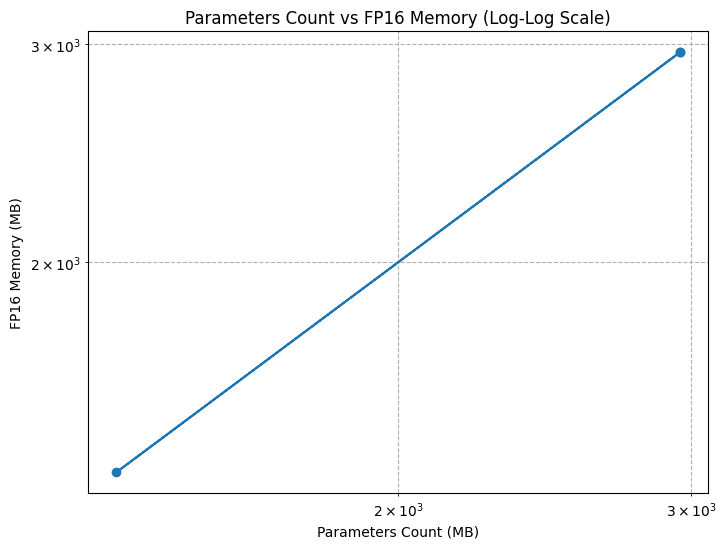

Completed!


In [12]:
param_counts = [small_param_memory, medium_param_memory, large_param_memory]
fp16_memories = [small_param_memory, medium_param_memory, large_param_memory]
plt.figure(figsize=(8, 6))
plt.loglog(param_counts, fp16_memories, marker='o')
plt.title('Parameters Count vs FP16 Memory (Log-Log Scale)')
plt.xlabel('Parameters Count (MB)')
plt.ylabel('FP16 Memory (MB)')
plt.grid(True, which="both", ls="--")
plt.show()


print('Completed!')

#Section 3

###Pre-flight Check

In [2]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"VRAM:{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch: 2.10.0+cu128
CUDA Available: True
Device: Tesla T4
VRAM:15.64 GB


In [3]:
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 14910 MiB


###Task 1: CPU Baseline

In [8]:
#GPT2 Small Model
print("\nGPT2 Small:")
with open("/content/gpt2_large.yaml", "r") as f:
    config_small = yaml.safe_load(f)

#print(config_small)
gpt2_small = GPT2_Model(config_small)
gpt2_small_model = gpt2_small.model()
gpt2_small_model = gpt2_small_model.to(device)

inputs = tokenizer(raw_text, return_tensors="pt").to(device)


GPT2 Small:


In [16]:
import time

start = time.perf_counter()

for idx in range(1):
  input_test = inputs.input_ids[0][idx:idx+512]

  with torch.no_grad():
      outputs = gpt2_small_model(input_test.unsqueeze(0), labels=input_test.unsqueeze(0), output_attentions=True)

cold_start_latency = time.perf_counter() - start
print(f"Cold Start (Time to First Token): {cold_start_latency * 1000:.2f} ms")

Cold Start (Time to First Token): 23445.44 ms


In [17]:
import time

start = time.perf_counter()
latencyl=[]
for idx in range(50):
  input_test = inputs.input_ids[0][idx:idx+512]

  with torch.no_grad():
      outputs = gpt2_small_model(input_test.unsqueeze(0), labels=input_test.unsqueeze(0), output_attentions=True)

  cold_start_latency = time.perf_counter() - start
  latencyl.append(cold_start_latency)
print(f"Cold Start (Time to First Token): {(sum(latencyl)/50) * 1000:.2f} ms")

Cold Start (Time to First Token): 541323.48 ms


In [18]:
torch.cuda.memory_allocated()

0

In [ ]:
# Free Small model before loading Medium
del gpt2_small_model, gpt2_small, outputs, inputs
torch.cuda.empty_cache()

###GPU Migration and basic acceleration